In [1]:

import numpy as np
import pandas as pd
import re
import string
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from wordcloud import WordCloud, STOPWORDS
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [2]:
df_beyondblue = pd.read_csv("beyondblue_swk.csv")
df_beyondblue.head()

,keyword,post_content_preview,thread_url,post_date,comments,num_comments,post_content_preview_clean,comments_clean,post_length,num_comments_length,post_text_lemmas,comments_lemma,post_month,post_year,year_month,severity_level
0,anxiety,Hi my name is Michelle and I have hadAnxietymy...,https://forums.beyondblue.org.au/t5/anxiety/an...,‎23-05-2025,"[""Dear Michelle ~Welcome here to the Support F...",2,michelle hadanxietymy life usually able contro...,dear michelle welcome good step anxiety coped ...,200,160,michelle hadanxietymy life usually able contro...,dear michelle welcome good step anxiety cope f...,5,2025,2025-05-01,Normal
1,anxiety,"Hi, I’ve suffered on and off fromanxietyover...",https://forums.beyondblue.org.au/t5/welcome-an...,‎28-05-2025,['Hello new member and welcome to the forum.Pl...,4,suffered fromanxietyover life recent years rea...,new member welcome forumplease arrived place n...,173,106,suffer fromanxietyover life recent year diffic...,new member welcome forumplease arrive place no...,5,2025,2025-05-01,Normal
2,anxiety,"I have had chronicanxietysince 2016, but I hav...",https://forums.beyondblue.org.au/t5/anxiety/an...,‎06-01-2025,"['Dear Guest-65543263,I can very much relate t...",9,chronicanxietysince managed bay medicationexer...,dear guest relate written perimenopause sympto...,186,966,chronicanxietysince manage bay medicationexerc...,dear guest relate write perimenopause symptom ...,1,2025,2025-01-01,Normal
3,anxiety,Hello I struggle with very badanxietyand panic...,https://forums.beyondblue.org.au/t5/anxiety/an...,‎04-03-2025,"['Hello any advice please would help', ""Hi don...",4,struggle badanxietyand panic attacks finally g...,advice ashamed struggle tell struggling helps ...,197,109,struggle badanxietyand panic attack finally go...,advice ashamed struggle tell struggle help lov...,3,2025,2025-03-01,Moderate
4,anxiety,I’ve recently sold my mortgage free home that ...,https://forums.beyondblue.org.au/t5/anxiety/an...,‎04-06-2025,"[""Hi KCT welcomeAnxiety is a serious condition...",3,recently sold mortgage free home lived years c...,kct welcomeanxiety condition underestimated po...,192,189,recently sell mortgage free home live year cit...,kct welcomeanxiety condition underestimate pot...,6,2025,2025-06-01,Normal


In [3]:
# VADER sentiment analysis on cleaned post text
analyzer = SentimentIntensityAnalyzer()
def _vader_scores(text):
    if pd.isna(text) or str(text).strip() == "":
        return pd.Series({'vader_neg': 0.0, 'vader_neu': 0.0, 'vader_pos': 0.0, 'vader_compound': 0.0})
    s = analyzer.polarity_scores(str(text))
    return pd.Series({'vader_neg': s['neg'], 'vader_neu': s['neu'], 'vader_pos': s['pos'], 'vader_compound': s['compound']})

# Choose the cleaned post text column (adjust if you prefer a different column)
text_col = 'post_content_preview_clean'

# Compute and attach scores
vader_df = df_beyondblue[text_col].apply(_vader_scores)
df_beyondblue = pd.concat([df_beyondblue, vader_df], axis=1)

# Add categorical sentiment label by VADER compound thresholds
df_beyondblue['vader_sentiment'] = df_beyondblue['vader_compound'].apply(
    lambda c: 'positive' if c >= 0.05 else ('negative' if c <= -0.05 else 'neutral')
)

# Quick check
print(df_beyondblue[[text_col, 'vader_compound', 'vader_sentiment']].head())
print("\nSentiment distribution:")
print(df_beyondblue['vader_sentiment'].value_counts())

                          post_content_preview_clean  vader_compound  \
0  michelle hadanxietymy life usually able contro...         -0.1280   
1  suffered fromanxietyover life recent years rea...         -0.7178   
2  chronicanxietysince managed bay medicationexer...          0.0000   
3  struggle badanxietyand panic attacks finally g...          0.2960   
4  recently sold mortgage free home lived years c...          0.5106   

  vader_sentiment  
0        negative  
1        negative  
2         neutral  
3        positive  
4        positive  

Sentiment distribution:
vader_sentiment
negative    12079
positive     4785
neutral      1402
Name: count, dtype: int64


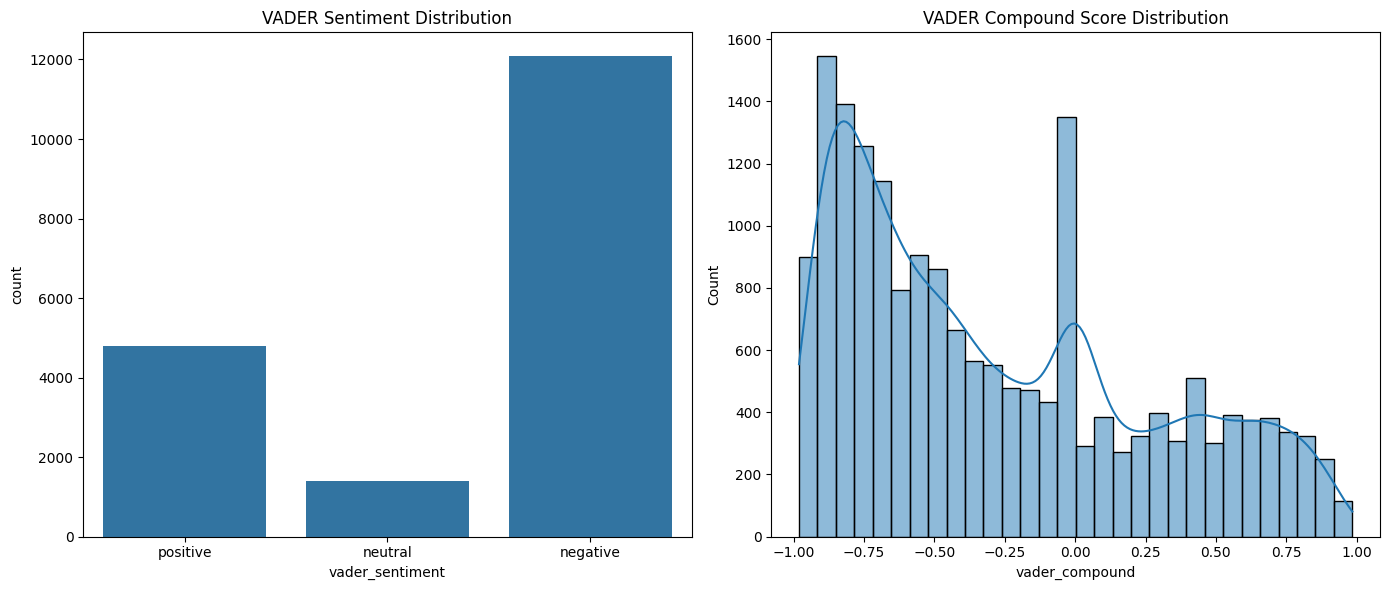

In [4]:
#visualization of the sentiment distribution and the vader component scores side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.countplot(x='vader_sentiment', data=df_beyondblue, order=['positive', 'neutral', 'negative'], ax=axes[0])
axes[0].set_title('VADER Sentiment Distribution')
sns.histplot(df_beyondblue['vader_compound'], bins=30, kde=True, ax=axes[1])
axes[1].set_title('VADER Compound Score Distribution')
plt.tight_layout()
plt.show()

In [5]:
from textblob import TextBlob

def _textblob_scores(text):
    if pd.isna(text) or str(text).strip() == "":
        return pd.Series({'tb_polarity': 0.0, 'tb_subjectivity': 0.0})
    tb = TextBlob(str(text))
    return pd.Series({'tb_polarity': tb.sentiment.polarity, 'tb_subjectivity': tb.sentiment.subjectivity})

# Compute and attach TextBlob scores (uses existing `df_beyondblue` and `text_col`)
tb_df = df_beyondblue[text_col].apply(_textblob_scores)
df_beyondblue = pd.concat([df_beyondblue, tb_df], axis=1)

# Add categorical sentiment label using simple polarity thresholds
df_beyondblue['tb_sentiment'] = df_beyondblue['tb_polarity'].apply(
    lambda p: 'positive' if p >= 0.05 else ('negative' if p <= -0.05 else 'neutral')
)

# Quick check
print(df_beyondblue[[text_col, 'tb_polarity', 'tb_subjectivity', 'tb_sentiment']].head())
print("\nTextBlob sentiment distribution:")
print(df_beyondblue['tb_sentiment'].value_counts())

                          post_content_preview_clean  tb_polarity  \
0  michelle hadanxietymy life usually able contro...    -0.066667   
1  suffered fromanxietyover life recent years rea...    -0.250000   
2  chronicanxietysince managed bay medicationexer...     0.250000   
3  struggle badanxietyand panic attacks finally g...     0.633333   
4  recently sold mortgage free home lived years c...    -0.013333   

   tb_subjectivity tb_sentiment  
0         0.608333     negative  
1         0.625000     negative  
2         0.250000     positive  
3         0.633333     positive  
4         0.423333      neutral  

TextBlob sentiment distribution:
tb_sentiment
positive    7372
negative    6169
neutral     4725
Name: count, dtype: int64


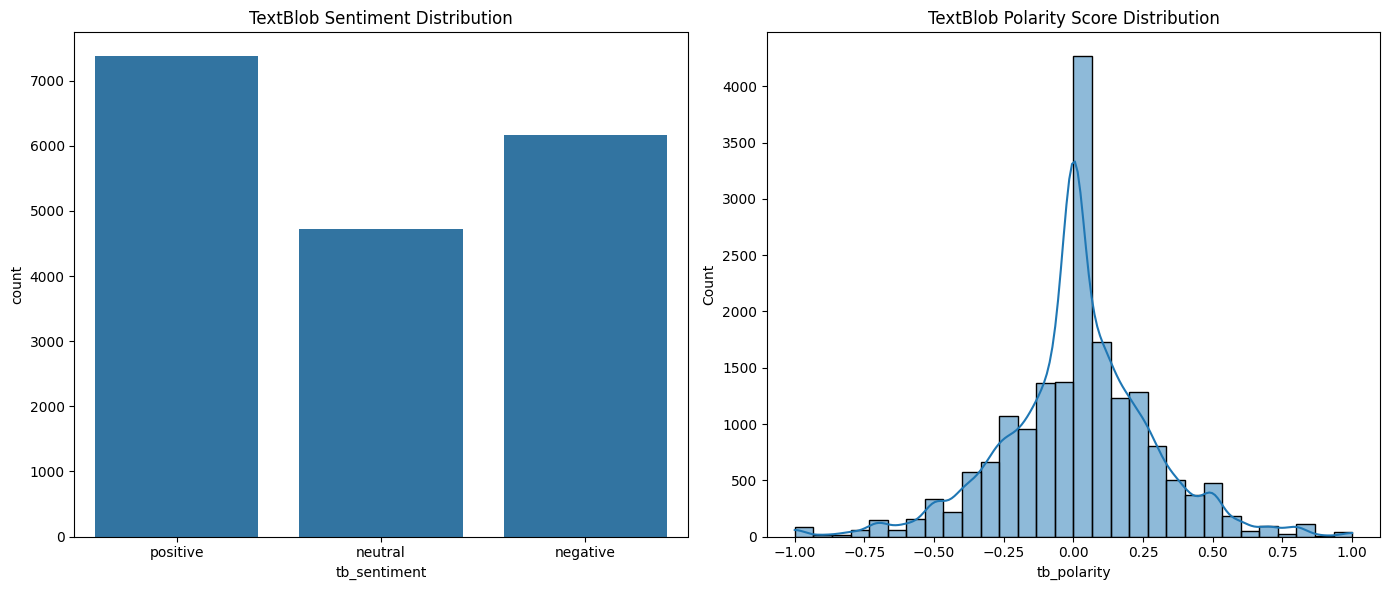

In [6]:
#do the same visualization for TextBlob sentiment
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.countplot(x='tb_sentiment', data=df_beyondblue, order=['positive', 'neutral', 'negative'], ax=axes[0])
axes[0].set_title('TextBlob Sentiment Distribution')
sns.histplot(df_beyondblue['tb_polarity'], bins=30, kde=True, ax=axes[1])
axes[1].set_title('TextBlob Polarity Score Distribution')
plt.tight_layout()
plt.show()

Otsu thresholds: -0.409146875 0.243759375
Jenks thresholds (internal): -0.4325 0.2197

Counts per method:
col_0       count
otsu_class       
negative     9273
neutral      5204
positive     3789
col_0        count
jenks_class       
negative      8990
neutral       5383
positive      3893
col_0      count
gmm_class       
negative    8997
neutral     5581
positive    3688

Cross-tabulation between methods:
gmm_class   negative  neutral  positive
otsu_class                             
negative        8997      276         0
neutral            0     5204         0
positive           0      101      3688


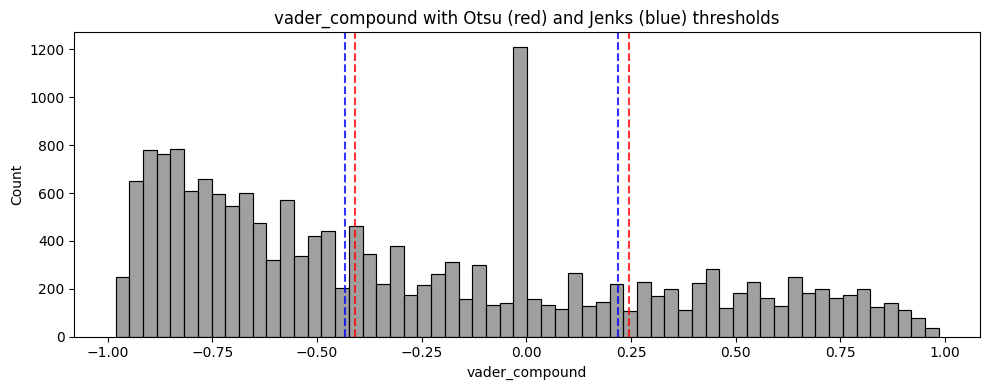

In [7]:
import numpy as np
from sklearn.mixture import GaussianMixture
import seaborn as sns
import pandas as pd

import matplotlib.pyplot as plt

vals = df_beyondblue['vader_compound'].dropna().values

# 1) Otsu multi-thresholding (exhaustive search for 2 thresholds -> 3 classes)
def otsu_multi_thresholds(data, nbins=256):
    counts, bin_edges = np.histogram(data, bins=nbins, range=(data.min(), data.max()))
    probs = counts.astype(float) / counts.sum()
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.0
    L = len(probs)
    best_sigma = -1
    best_t = (0, 0)
    # two thresholds t1, t2 (indices)
    for t1 in range(1, L - 1):
        w0 = probs[:t1].sum()
        if w0 == 0: continue
        mu0 = (probs[:t1] * bin_centers[:t1]).sum() / w0
        for t2 in range(t1 + 1, L):
            w1 = probs[t1:t2].sum()
            w2 = probs[t2:].sum()
            if w1 == 0 or w2 == 0: continue
            mu1 = (probs[t1:t2] * bin_centers[t1:t2]).sum() / w1
            mu2 = (probs[t2:] * bin_centers[t2:]).sum() / w2
            muT = (probs * bin_centers).sum()
            sigma_b = w0 * (mu0 - muT) ** 2 + w1 * (mu1 - muT) ** 2 + w2 * (mu2 - muT) ** 2
            if sigma_b > best_sigma:
                best_sigma = sigma_b
                best_t = (bin_centers[t1], bin_centers[t2])
    return best_t

otsu_t1, otsu_t2 = otsu_multi_thresholds(vals)
df_beyondblue['otsu_class'] = pd.cut(df_beyondblue['vader_compound'],
                                     bins=[-np.inf, otsu_t1, otsu_t2, np.inf],
                                     labels=['negative', 'neutral', 'positive'])

# 2) Jenks (Fisher–Jenks) natural breaks (k=3)
def jenks_breaks(data, n_classes):
    data = np.sort(data)
    n_data = len(data)
    mat1 = np.zeros((n_data + 1, n_classes + 1))
    mat2 = np.zeros((n_data + 1, n_classes + 1))
    for i in range(1, n_classes + 1):
        mat1[0, i] = 1
        mat2[0, i] = 0
        for j in range(1, n_data + 1):
            mat2[j, i] = np.inf
    var = 0.0
    for l in range(1, n_data + 1):
        s1 = s2 = w = 0.0
        for m in range(1, l + 1):
            i3 = l - m + 1
            val = data[i3 - 1]
            s2 += val * val
            s1 += val
            w += 1
            var = s2 - (s1 * s1) / w
            i4 = i3 - 1
            if i4 != 0:
                for j in range(2, n_classes + 1):
                    if mat2[l, j] >= (var + mat2[i4, j - 1]):
                        mat1[l, j] = i3
                        mat2[l, j] = var + mat2[i4, j - 1]
        mat1[l, 1] = 1
        mat2[l, 1] = var
    k = n_data
    kclass = [0.0] * (n_classes + 1)
    kclass[n_classes] = data[-1]
    count_num = n_classes
    while count_num >= 2:
        idx = int(mat1[k, count_num] - 2)
        kclass[count_num - 1] = data[idx]
        k = int(mat1[k, count_num] - 1)
        count_num -= 1
    kclass[0] = data[0]
    return kclass

jenks_bounds = jenks_breaks(vals, 3)  # returns [min, b1, b2, max]
# Use the internal breakpoints (exclude min and max)
jb1, jb2 = jenks_bounds[1], jenks_bounds[2]
df_beyondblue['jenks_class'] = pd.cut(df_beyondblue['vader_compound'],
                                      bins=[-np.inf, jb1, jb2, np.inf],
                                      labels=['negative', 'neutral', 'positive'])

# 3) Gaussian Mixture Model (3 components)
gmm = GaussianMixture(n_components=3, random_state=0)
gmm.fit(vals.reshape(-1, 1))
gmm_labels = gmm.predict(df_beyondblue['vader_compound'].fillna(0).values.reshape(-1, 1))
# order components by mean to get consistent negative/neutral/positive mapping
means = gmm.means_.flatten()
order = np.argsort(means)
label_map = {int(old): new for new, old in enumerate(order)}  # map old->ordered 0..2
ordered_labels = np.array([label_map[int(l)] for l in gmm_labels])
label_names = np.array(['negative', 'neutral', 'positive'])
df_beyondblue['gmm_class'] = label_names[ordered_labels]

# Quick cross-check summaries
print("Otsu thresholds:", otsu_t1, otsu_t2)
print("Jenks thresholds (internal):", jb1, jb2)
print("\nCounts per method:")
print(pd.crosstab(index=df_beyondblue['otsu_class'], columns='count'))
print(pd.crosstab(index=df_beyondblue['jenks_class'], columns='count'))
print(pd.crosstab(index=df_beyondblue['gmm_class'], columns='count'))

print("\nCross-tabulation between methods:")
print(pd.crosstab(df_beyondblue['otsu_class'], df_beyondblue['gmm_class']))

# Optional: quick visualization
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
sns.histplot(df_beyondblue['vader_compound'], bins=60, kde=False, ax=ax, color='gray')
for thr in [otsu_t1, otsu_t2, jb1, jb2]:
    ax.axvline(thr, linestyle='--', color='red' if thr in (otsu_t1, otsu_t2) else 'blue', alpha=0.8)
ax.set_title('vader_compound with Otsu (red) and Jenks (blue) thresholds')
plt.tight_layout()
plt.show()

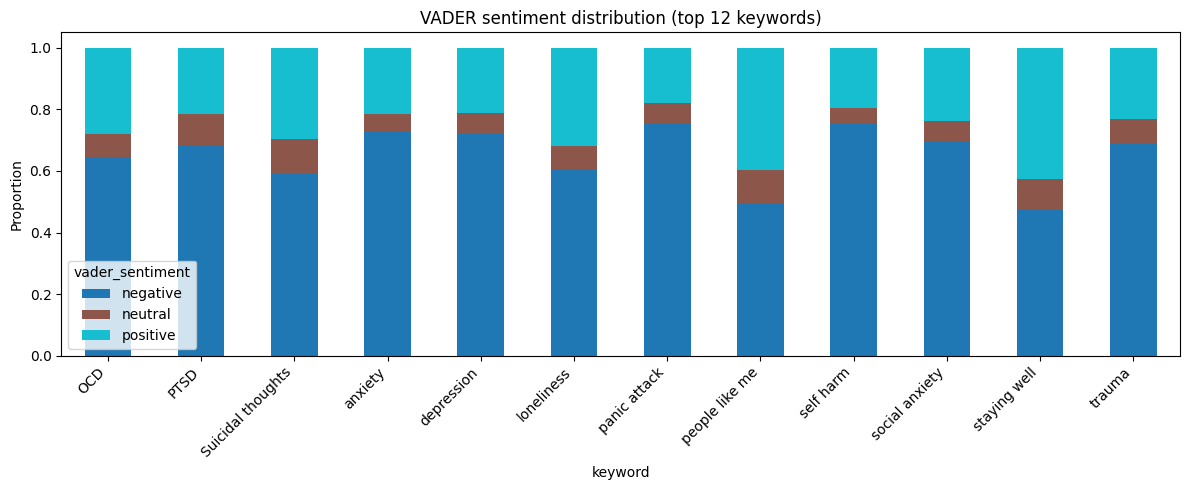

Top 10 topics by VADER positive proportion:
keyword
staying well         0.426772
people like me       0.397793
loneliness           0.320216
Suicidal thoughts    0.294816
OCD                  0.279610
social anxiety       0.237401
trauma               0.232813
PTSD                 0.214429
anxiety              0.214367
depression           0.213404
Name: positive, dtype: float64

Top 10 topics by VADER negative proportion:
keyword
suicidal thoughts    0.780204
panic attack         0.757009
self harm            0.752184
anxiety              0.729761
depression           0.718989
social anxiety       0.697025
trauma               0.689844
PTSD                 0.685371
OCD                  0.645427
loneliness           0.607253
Name: negative, dtype: float64


In [12]:
# Sentiment breakdowns by condition/topic and simple clustering of sentiment scores.

# 1) Sentiment distribution by condition (use top N keywords to keep plots readable)
top_n = 12
top_keywords = df_beyondblue['keyword'].value_counts().nlargest(top_n).index

ct_vader = pd.crosstab(df_beyondblue.loc[df_beyondblue['keyword'].isin(top_keywords), 'keyword'],
                       df_beyondblue.loc[df_beyondblue['keyword'].isin(top_keywords), 'vader_sentiment'])
ct_vader_norm = ct_vader.div(ct_vader.sum(axis=1), axis=0)

ax = ct_vader_norm.plot(kind='bar', stacked=True, figsize=(12, 5), colormap='tab10')
ax.set_ylabel('Proportion')
ax.set_title(f'VADER sentiment distribution (top {top_n} keywords)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 2) Which topics produce more positive / negative sentiment (rank by proportion)
prop_vader = pd.crosstab(df_beyondblue['keyword'], df_beyondblue['vader_sentiment'], normalize='index').fillna(0)
top_positive_topics = prop_vader['positive'].sort_values(ascending=False).head(10)
top_negative_topics = prop_vader['negative'].sort_values(ascending=False).head(10)

print("Top 10 topics by VADER positive proportion:")
print(top_positive_topics)
print("\nTop 10 topics by VADER negative proportion:")
print(top_negative_topics)



In [8]:
# convert the dataframe to csv file
df_beyondblue.to_csv("beyondblue_severity.csv")
